## Objective — Data Preprocessing & Exploratory Data Analysis (EDA)

- Load and validate structured real-estate tabular data from the raw training dataset.
- Support **dual-mode execution** (sample mode for rapid iteration and full-data mode for final training) using a configurable runtime switch.
- Perform data cleaning by handling missing target values and ensuring schema consistency.
- Select and isolate predictive numerical features relevant to property valuation.
- Analyze statistical distributions and central tendencies of target and feature variables.
- Examine inter-feature and feature-target correlations to understand linear relationships.
- Investigate the spatial distribution of properties using latitude and longitude.
- Generate visual diagnostics to support feature relevance justification.
- Export a clean, model-ready feature matrix (`X`) and target vector (`y`) for downstream training.



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


USE_SAMPLE = False       # Toggle between sample mode (True) and full dataset (False)
SAMPLE_SIZE = 500       
RANDOM_STATE = 42        # Seed for reproducibility

# Execution mode identifier 
RUN_MODE = "sample" if USE_SAMPLE else "full"




In [ ]:

df = pd.read_excel("data/train.xlsx")


df = df.sort_values("id").reset_index(drop=True)


# Optional runtime sampling for faster experimentation

if USE_SAMPLE:
    df = df.iloc[:SAMPLE_SIZE]

df.head()



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1000102,20140916T000000,280000,6,3.00,2400,9373,2.0,0,0,...,7,2400,0,1991,0,98002,47.3262,-122.214,2060,7316
1,1200019,20140508T000000,647500,4,1.75,2060,26036,1.0,0,0,...,8,1160,900,1947,0,98166,47.4444,-122.351,2590,21891
2,1200021,20140811T000000,400000,3,1.00,1460,43000,1.0,0,0,...,7,1460,0,1952,0,98166,47.4434,-122.347,2250,20023
3,2800031,20150401T000000,235000,3,1.00,1430,7599,1.5,0,0,...,6,1010,420,1930,0,98168,47.4783,-122.265,1290,10320
4,3600057,20150319T000000,402500,4,2.00,1650,3504,1.0,0,0,...,7,760,890,1951,2013,98144,47.5803,-122.294,1480,3504


In [ ]:

df = df.dropna(subset=["price"])  
df = df.reset_index(drop=True)    


In [ ]:

# Defining target variable and selected predictive features

TARGET = "price"

FEATURE_COLS = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "lat",
    "long"
]


# Spliting dataset into features (X) and target (y)

X = df[FEATURE_COLS]
y = df[TARGET]



In [ ]:

# Validating presence of required feature and target columns

missing_cols = set(FEATURE_COLS + [TARGET]) - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")



In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             500 non-null    int64  
 1   date           500 non-null    object 
 2   price          500 non-null    int64  
 3   bedrooms       500 non-null    int64  
 4   bathrooms      500 non-null    float64
 5   sqft_living    500 non-null    int64  
 6   sqft_lot       500 non-null    int64  
 7   floors         500 non-null    float64
 8   waterfront     500 non-null    int64  
 9   view           500 non-null    int64  
 10  condition      500 non-null    int64  
 11  grade          500 non-null    int64  
 12  sqft_above     500 non-null    int64  
 13  sqft_basement  500 non-null    int64  
 14  yr_built       500 non-null    int64  
 15  yr_renovated   500 non-null    int64  
 16  zipcode        500 non-null    int64  
 17  lat            500 non-null    float64
 18  long      

In [29]:
df.describe()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,5.000000e+02,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,1.654822e+08,5.481171e+05,3.442000,2.218500,2172.922000,22601.706000,1.507000,0.012000,0.294000,3.35400,7.698000,1910.532000,262.390000,1972.790000,111.516000,98080.24400,47.572393,-122.206904,2092.016000,19167.754000
std,7.988017e+07,3.427165e+05,0.931865,0.848276,928.420207,58776.412929,0.511835,0.108994,0.858509,0.62407,1.287677,906.852723,419.767492,28.714159,458.334645,57.68271,0.138790,0.162704,747.878327,51341.590558
min,1.000102e+06,1.025000e+05,1.000000,0.000000,530.000000,1002.000000,1.000000,0.000000,0.000000,2.00000,5.000000,530.000000,0.000000,1901.000000,0.000000,98001.00000,47.203200,-122.511000,750.000000,1201.000000
25%,1.045605e+08,3.257500e+05,3.000000,1.750000,1487.500000,6031.500000,1.000000,0.000000,0.000000,3.00000,7.000000,1250.000000,0.000000,1954.750000,0.000000,98029.50000,47.492500,-122.354250,1537.500000,6031.750000
50%,1.911001e+08,4.730000e+05,3.000000,2.250000,2010.000000,8392.500000,1.500000,0.000000,0.000000,3.00000,7.000000,1610.000000,0.000000,1976.500000,0.000000,98070.00000,47.586250,-122.231500,1970.000000,8198.500000
75%,2.392501e+08,6.503250e+05,4.000000,2.500000,2620.000000,14948.750000,2.000000,0.000000,0.000000,4.00000,8.000000,2412.500000,500.000000,1998.000000,0.000000,98126.00000,47.681550,-122.104000,2462.500000,12448.250000
max,2.900001e+08,3.204000e+06,7.000000,5.250000,5545.000000,871200.000000,3.000000,1.000000,4.000000,5.00000,12.000000,5400.000000,2180.000000,2015.000000,2014.000000,98199.00000,47.777400,-121.417000,4700.000000,871200.000000


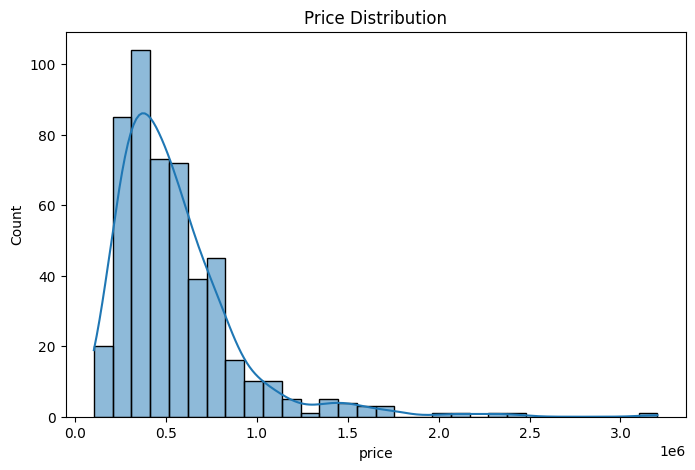

In [ ]:

# Visualisation of distribution of property prices

plt.figure(figsize=(8, 5))
sns.histplot(y, bins=30, kde=True)

plt.title("Price Distribution")

plt.tight_layout()
plt.show()


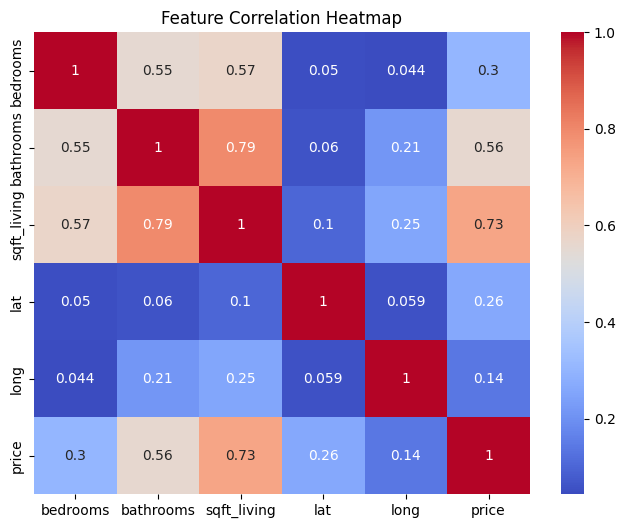

In [ ]:

# Visualisation of correlation structure among selected features and target

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[FEATURE_COLS + [TARGET]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()


    

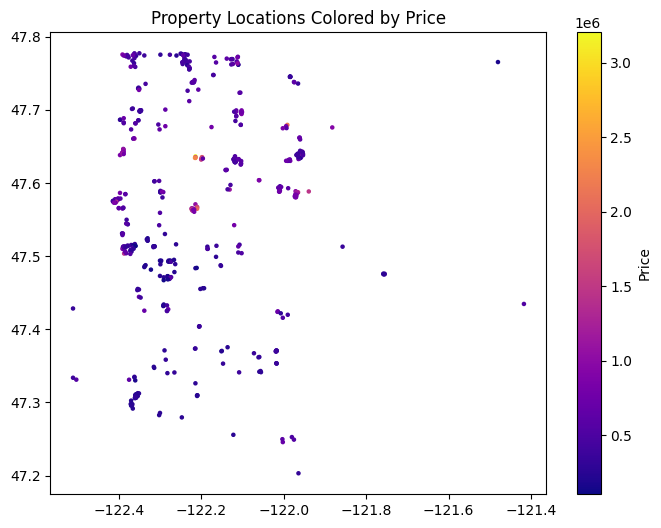

In [ ]:

# Visualisation of spatial distribution of properties with price encoding

plt.figure(figsize=(8, 6))

# Scatter plot of longitude vs latitude, colored by property price
plt.scatter(
    df["long"],
    df["lat"],
    c=y,
    cmap="plasma",
    s=5
)


plt.colorbar(label="Price")
plt.title("Property Locations Colored by Price")

plt.tight_layout()
plt.show()





In [ ]:

# Exporting processed features and target for downstream model training

X.to_csv(f"data/X_features_{RUN_MODE}.csv", index=False)
y.to_csv(f"data/y_target_{RUN_MODE}.csv", index=False)

print("✅ Preprocessing complete")





✅ Preprocessing complete


## Observations — Key Insights from Preprocessing & EDA

- Property prices exhibit a **right-skewed distribution**, indicating the presence of high-value outliers.
- Size-related features (e.g., `sqft_living`, `bathrooms`) show **strong positive correlation** with property price.
- Geographical coordinates (`lat`, `long`) contribute meaningful but **non-linear spatial influence** on pricing.
- Latitude demonstrates a stronger relationship with price compared to longitude, suggesting location-dependent valuation zones.
- Bedrooms alone have moderate explanatory power, but their effect strengthens when combined with living area.
- Feature correlation analysis indicates limited multicollinearity among selected predictors.
- Spatial scatter plots reveal **price clustering**, supporting the use of location-based proxy features.
- The preprocessing pipeline produces a **consistent, reproducible dataset** across sample and full-data modes.
- Exported datasets (`X_features_*.csv`, `y_target_*.csv`) ensure clean separation between preprocessing and modeling stages.